In [ ]:
import os
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
from maomao.dataset_description.graph_distribution_analysis import *

### Toxicity dataset composition and endpoint co-occurrence analysis

This notebook characterizes the curated peptide toxicity dataset by analyzing the distribution of toxicity endpoints, ambiguous annotations, and descriptor summaries. It computes endpoint-level composition, identifies peptides associated with multiple toxicity categories, and visualizes toxicity endpoint co-occurrence through summary plots and heatmaps.


- Read data

In [14]:
df_pivote_class = pd.read_csv("../../processed_data/processed_data/processed_toxic_dataset.csv")
df_ambiguous = pd.read_csv("../../processed_data/processed_data/processed_ambiguous_dataset.csv")

- Graph of number of effects per sequences

In [15]:
combination_counts, cooccurrence_matrix, df_top_level = compute_top_level_toxicity_summary(df=df_pivote_class)

- Plot dataset composition by endpoint

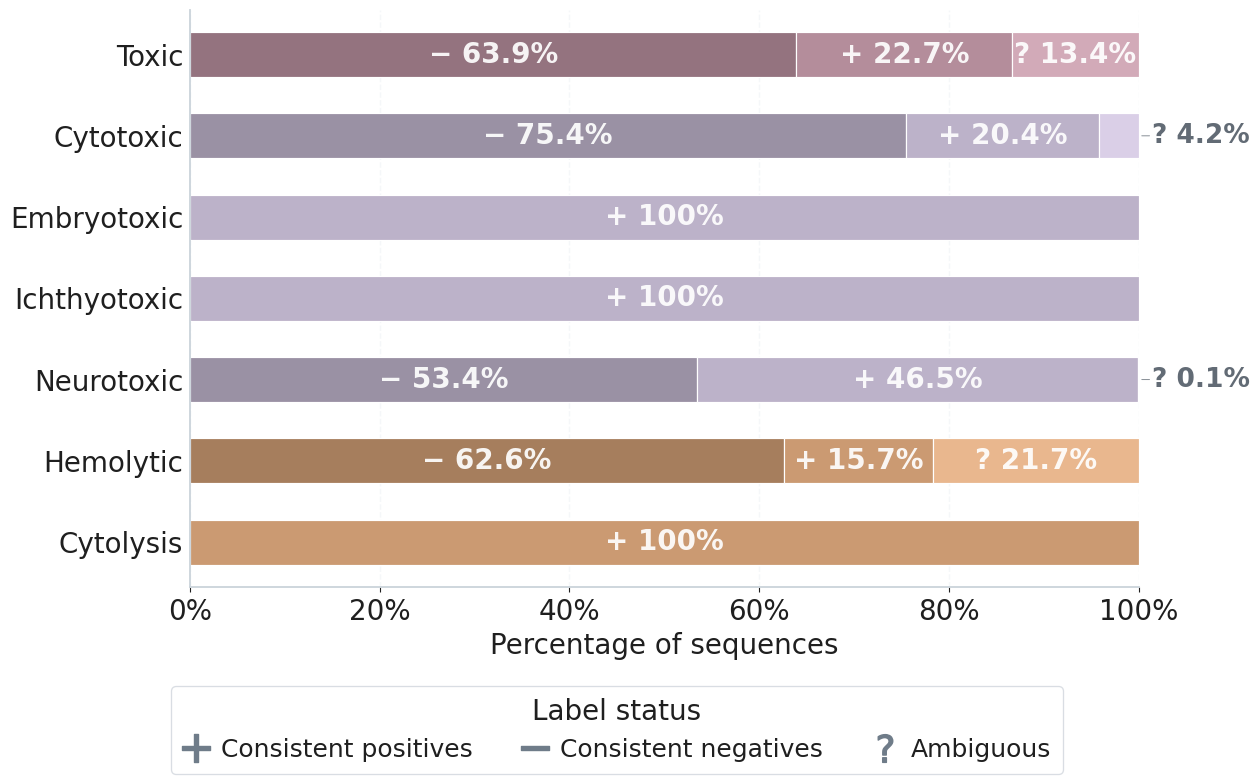

In [16]:
colors = {
    "toxic": "#CDA0B0",
    "cytotoxic": "#D6CAE4",
    "neurotoxic": "#D6CAE4",
    "hemolytic": "#E7AF81",
    "embryotoxic": "#D6CAE4",
    "ichthyotoxic": "#D6CAE4", 
    "cytolysis": "#E7AF81"
}

fig, ax, summary_counts, summary_pct = plot_dataset_composition_by_endpoint_horizontal(
    df_main=df_pivote_class,
    df_amb=df_ambiguous,
    title_fontsize=18,  
    tick_fontsize=20,   
    label_fontsize=20,  
    annot_fontsize=20,  
    legend_fontsize=18, 
    legend_title_fontsize=20,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.45, -0.15),
    legend_marker_size=20,
    bold_fonts=False,
    figsize=(13, 8),
    endpoint_colors=colors
)
#fig.savefig("plot_dataset_composition_by_endpoint_horizontal.png", dpi=800)

- Plot effect cooccurrence

In [17]:
results = compute_effect_cooccurrence(df_pivote_class)

cooccurrence_matrix = results["cooccurrence_matrix"]
row_totals = results["row_totals"]
effect_binary = results["effect_binary"]
summary = results["summary"]

cooccurrence_matrix

,cytotoxic,embryotoxic,ichthyotoxic,neurotoxic,hemolytic,cytolysis
cytotoxic,5317,0,5,26,4867,341
embryotoxic,0,2,0,0,0,0
ichthyotoxic,5,0,5,0,2,5
neurotoxic,26,0,0,1481,9,12
hemolytic,4867,0,2,9,4867,151
cytolysis,341,0,5,12,151,341


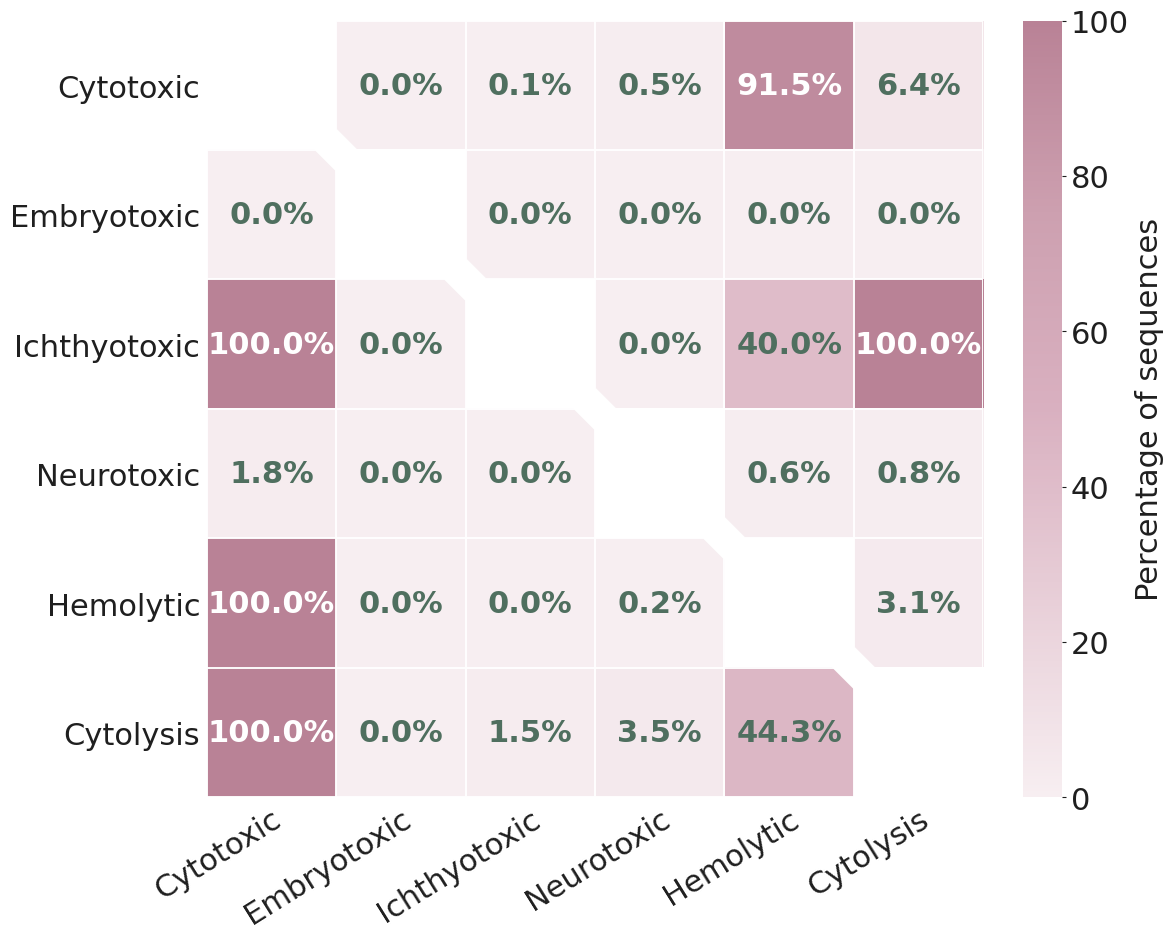

In [18]:
fig, ax, im, cbar, overlap_pct = plot_all_effects_cooccurrence_heatmap(
    cooccurrence_matrix=cooccurrence_matrix,
    row_totals=row_totals,
    cbar_label="Percentage of sequences",
    #save_path="all_effects_cooccurrence_heatmap.png",
    figsize=(12, 9.5)
)